In [67]:
import os

if os.path.exists("lab2"):
    os.chdir("lab2")

In [68]:
import pandas as pd

In [69]:
voltages = pd.read_csv("voltages.csv")

In [70]:
voltages

,index,stopping_voltage,voltage_unc,wavelength,filter_wavelength
0,0,289.53,0.01,640,NaN
1,1,325.54,0.01,626,NaN
2,2,384.40,0.10,604,NaN
3,3,416.00,0.10,590,NaN
4,4,461.00,0.10,570,NaN
5,5,534.40,0.10,525,NaN
6,6,553.60,0.10,505,NaN
7,7,650.10,0.10,470,NaN
8,8,737.90,0.10,455,436.0
9,9,884.20,0.10,400,405.0


In [83]:
import pandas as pd


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


def find_data_from_spectrometer(filepath):
    df = pd.read_csv(filepath, header=0, names=["wavelength", "intensity"])
    max_intensity = df["intensity"].max()
    max_index = df["intensity"].idxmax()
    max_wavelength = df["wavelength"].iloc[max_index]

    # Fit Gaussian to the data
    x_data = df["wavelength"]
    y_data = df["intensity"]

    popt, pcov = curve_fit(
        gaussian, x_data, y_data, p0=[max_intensity, x_data[max_index], np.std(x_data)]
    )

    # Plot the data and the Gaussian fit
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [2, 1]}
    )

    ax1.scatter(x_data, y_data, label="Experimental Data")

    # Generate smooth x values for the fit curve
    x_fit = np.linspace(x_data.min(), x_data.max(), 200)
    y_fit = gaussian(x_fit, *popt)
    ax1.plot(x_fit, y_fit, "r-", label="Gaussian Fit")

    # Calculate 68% confidence interval (1 standard deviation)
    mu, sigma = popt[1], abs(popt[2])
    lower_bound = mu - sigma
    upper_bound = mu + sigma

    ax1.axvline(lower_bound, color="g", linestyle="--", label="68% Confidence Interval")
    ax1.axvline(upper_bound, color="g", linestyle="--")

    ax1.set_title(
        "Gaussian Model Fit to Intensity vs. Wavelength Spectrometer Data, Wavelength = 570nm"
    )
    ax1.set_xlabel("Wavelength")
    ax1.set_ylabel("Intensity")
    ax1.legend()

    # # Annotate the interval bounds
    # ax1.annotate(
    #     f"{lower_bound:.2f}",
    #     xy=(lower_bound, ax1.get_ylim()[1]),
    #     xytext=(10, 10),
    #     textcoords="offset points",
    # )
    # ax1.annotate(
    #     f"{upper_bound:.2f}",
    #     xy=(upper_bound, ax1.get_ylim()[1]),
    #     xytext=(10, 10),
    #     textcoords="offset points",
    # )

    width = upper_bound - lower_bound
    half_width = width / 2

    # Add a separate panel for confidence interval details
    ax2.axis("off")
    ax2.text(
        0.1,
        0.5,
        f"Confidence Interval (68%):\n\n"
        f"Center (μ): {mu:.2f} nm\n"
        f"Lower Bound: {lower_bound:.2f} nm\n"
        f"Upper Bound: {upper_bound:.2f} nm\n"
        f"Interval Width: {width:.2f} nm\n"
        f"Half-Width: {half_width:.2f} nm\n"
        f"Max-Intensity Wavelength: {int(max_wavelength)} nm",
        bbox=dict(facecolor="white", alpha=0.5),
    )

    plt.tight_layout()
    plt.savefig("spectrometer/570.png")
    plt.show()

    return {
        "df": df,
        "max_intensity": max_intensity,
        "max_wavelength": max_wavelength,
        "center": mu,
        "width": width,
        "half_width": half_width,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
    }


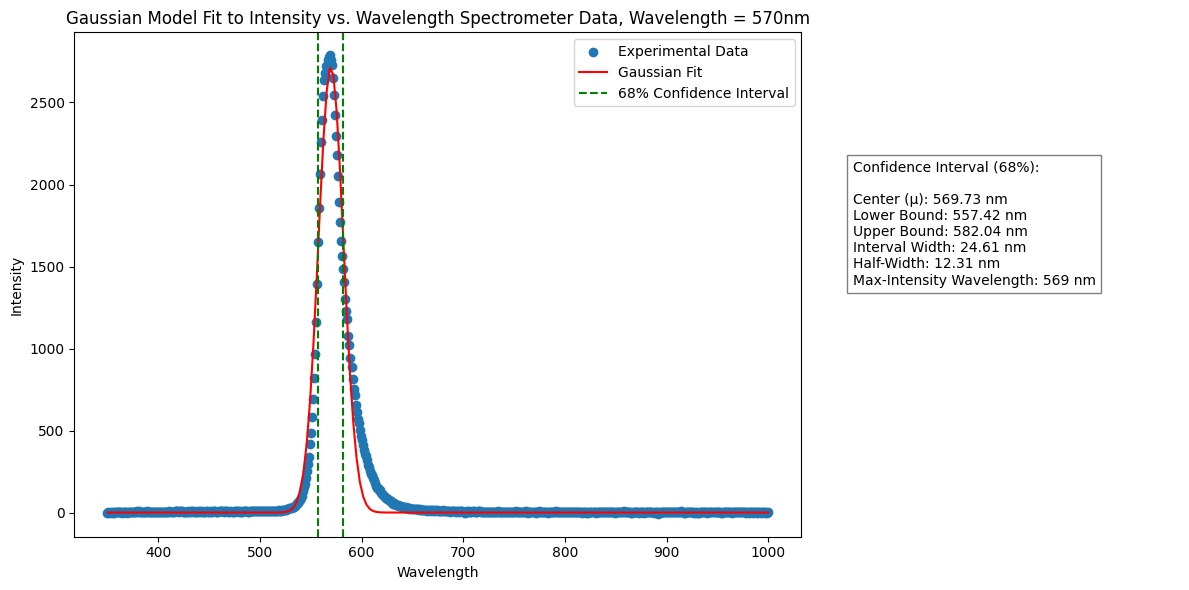

{'df':      wavelength  intensity
 0           350      -0.64
 1           351       0.72
 2           352      -0.36
 3           353       0.77
 4           354      -0.49
 ..          ...        ...
 646         996       4.73
 647         997      -0.35
 648         998       1.65
 649         999      -0.73
 650        1000       2.98
 
 [651 rows x 2 columns],
 'max_intensity': np.float64(2788.01),
 'max_wavelength': np.int64(569),
 'center': np.float64(569.7305074653798),
 'width': np.float64(24.614969441860694),
 'half_width': np.float64(12.307484720930347),
 'lower_bound': np.float64(557.4230227444494),
 'upper_bound': np.float64(582.0379921863101)}

In [85]:
find_data_from_spectrometer("spectrometer/570.csv")

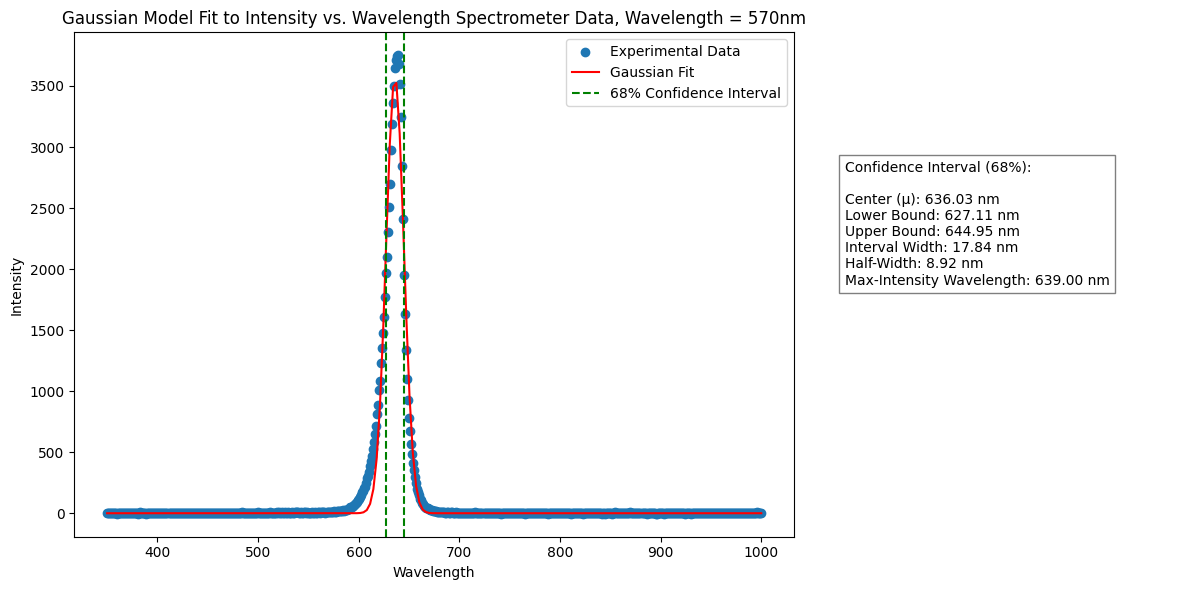

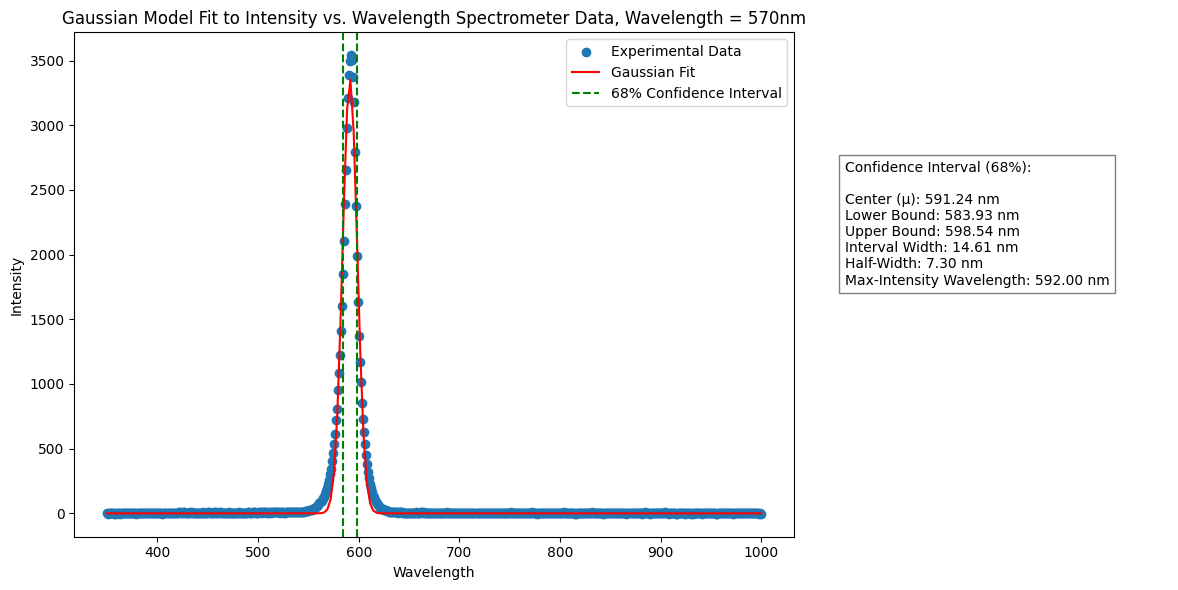

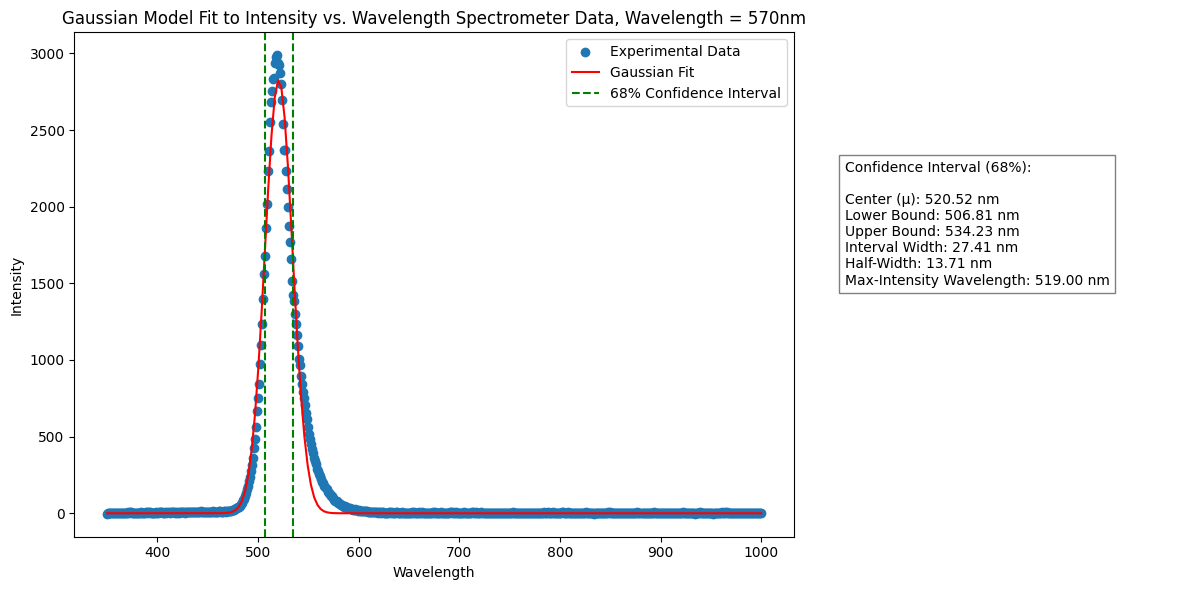

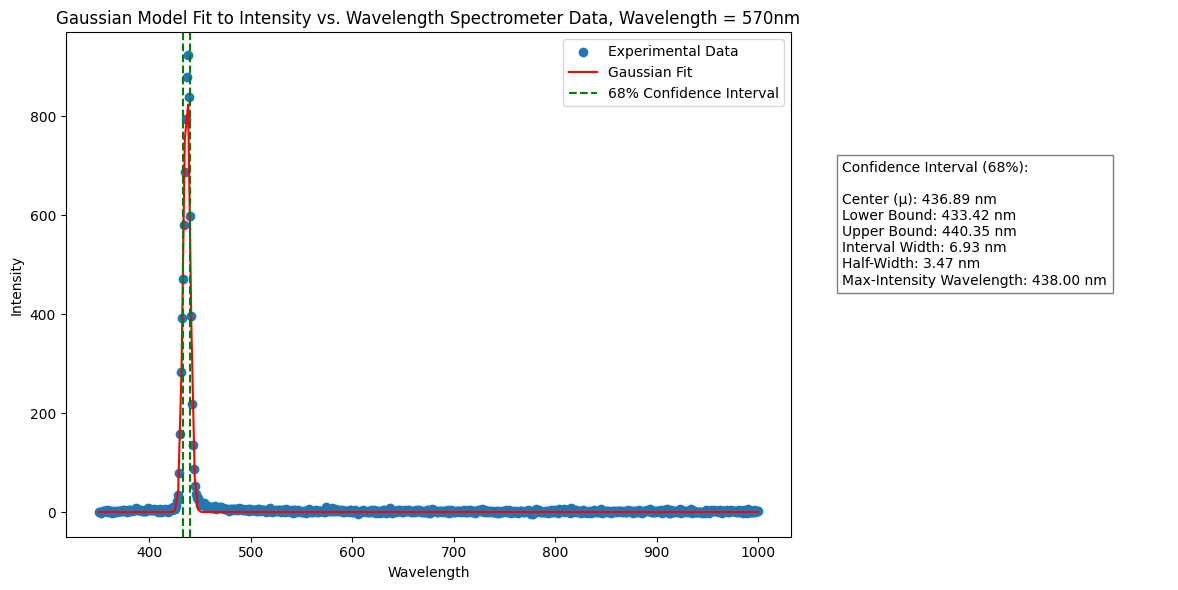

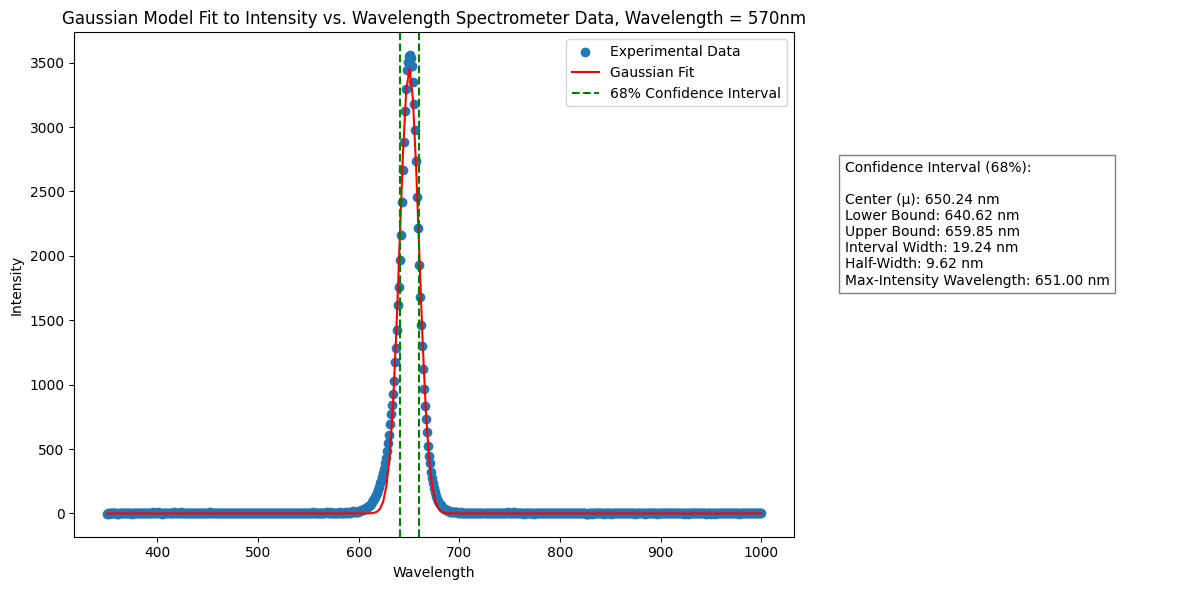

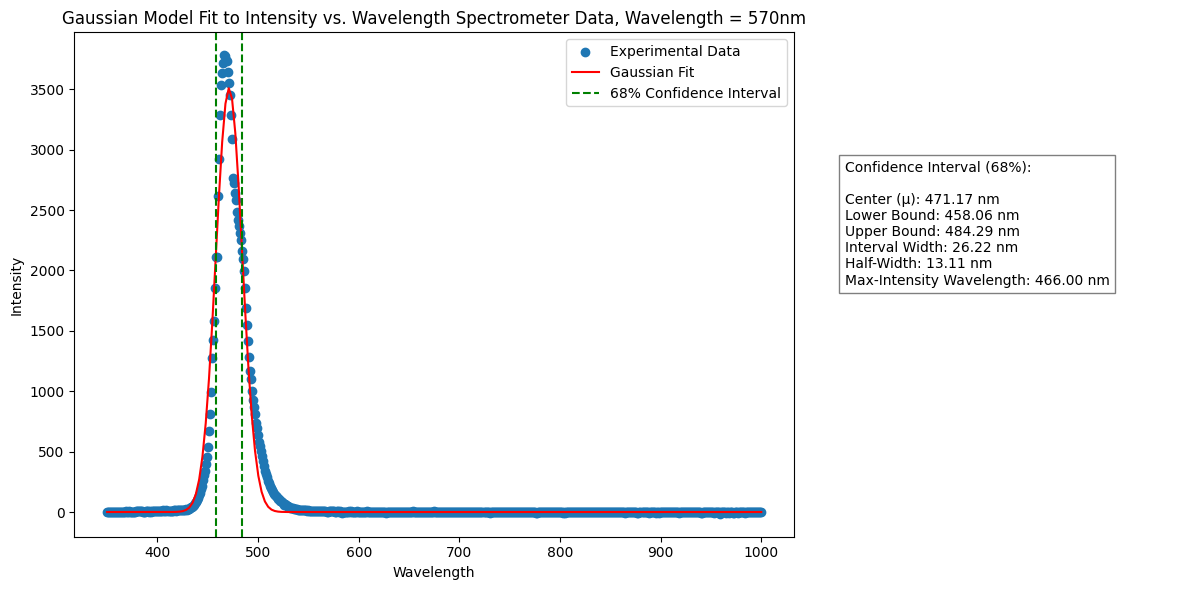

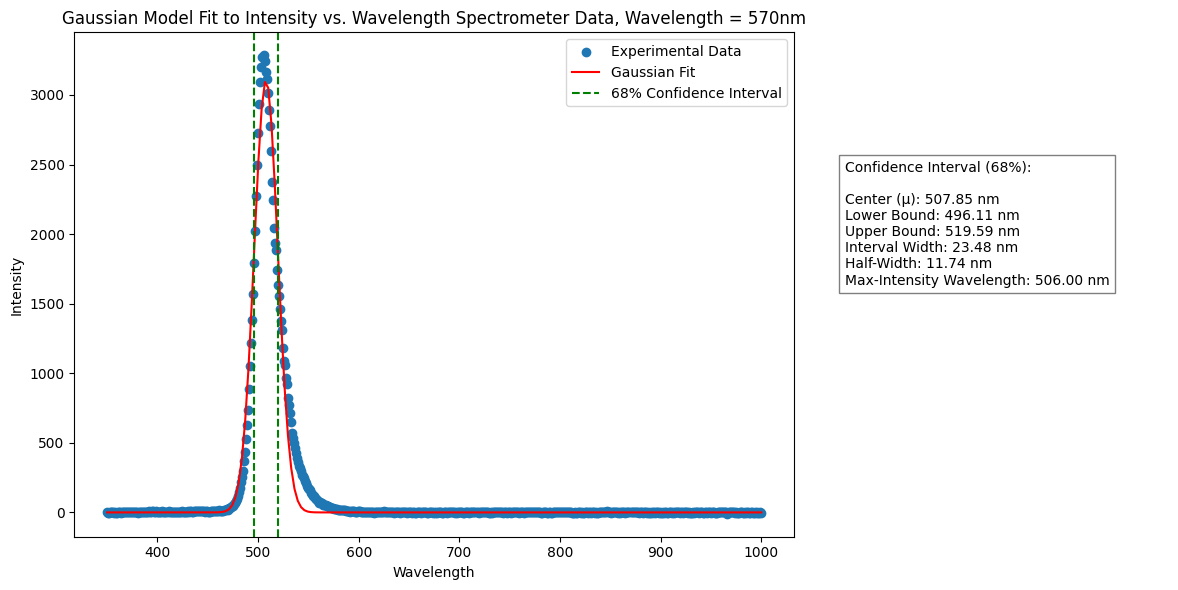

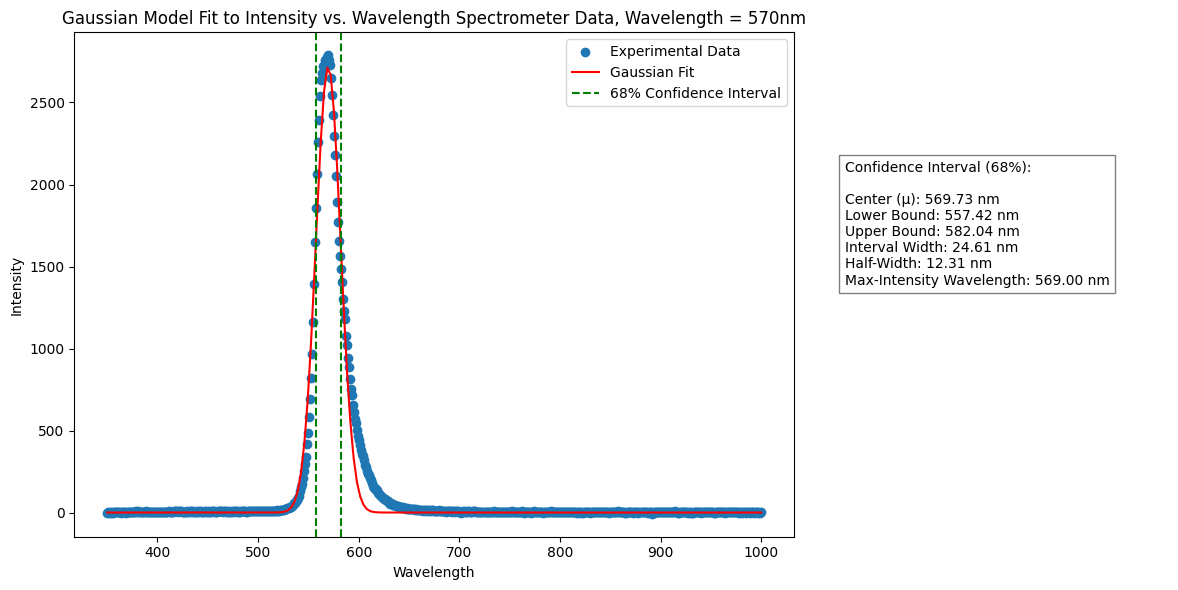

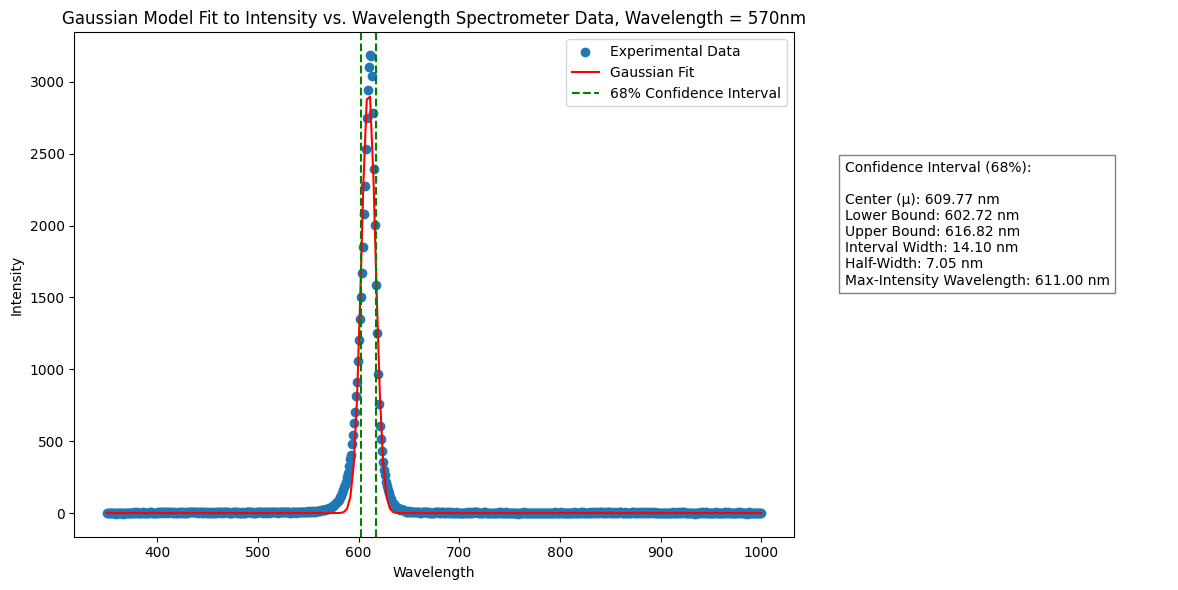

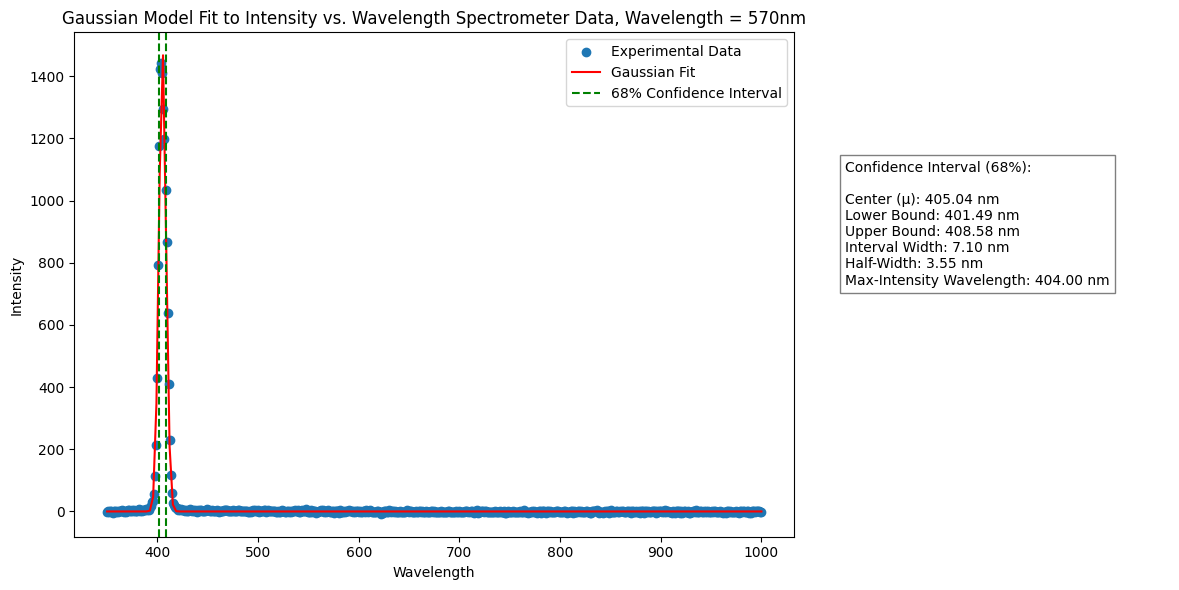

In [73]:
import os
import pandas as pd

confidence_intervals = []

for filename in os.listdir("spectrometer"):
    if filename.endswith(".csv"):
        wavelength = int(filename.split(".")[0])
        result = find_data_from_spectrometer(f"spectrometer/{filename}")
        result.update({"wavelength": wavelength})

        confidence_intervals.append(result)

spect_df = pd.DataFrame(confidence_intervals)
spect_df = spect_df.sort_values("wavelength")

spect_df.to_csv("spect_df.csv", index=False)

In [74]:
spect_df

,df,max_intensity,max_wavelength,center,width,half_width,lower_bound,upper_bound,wavelength
9,wavelength intensity 0 350 ...,1443.94,404,405.036525,7.096387,3.548193,401.488332,408.584718,400
3,wavelength intensity 0 350 ...,923.71,438,436.885622,6.931332,3.465666,433.419956,440.351288,455
5,wavelength intensity 0 350 ...,3781.90,466,471.174059,26.222154,13.111077,458.062982,484.285136,470
6,wavelength intensity 0 350 ...,3285.43,506,507.851198,23.477717,11.738859,496.112339,519.590057,505
2,wavelength intensity 0 350 ...,2988.05,519,520.519002,27.413492,13.706746,506.812256,534.225748,525
7,wavelength intensity 0 350 ...,2788.01,569,569.730507,24.614969,12.307485,557.423023,582.037992,570
1,wavelength intensity 0 350 ...,3540.87,592,591.237186,14.607901,7.303951,583.933235,598.541136,590
8,wavelength intensity 0 350 ...,3184.15,611,609.771959,14.100858,7.050429,602.721530,616.822388,604
0,wavelength intensity 0 350 ...,3751.70,639,636.030057,17.843593,8.921797,627.108261,644.951854,626
4,wavelength intensity 0 350 ...,3557.30,651,650.235187,19.237819,9.618909,640.616278,659.854097,640


In [75]:
volt_df = pd.read_csv("voltages.csv")
volt_df

,index,stopping_voltage,voltage_unc,wavelength,filter_wavelength
0,0,289.53,0.01,640,NaN
1,1,325.54,0.01,626,NaN
2,2,384.40,0.10,604,NaN
3,3,416.00,0.10,590,NaN
4,4,461.00,0.10,570,NaN
5,5,534.40,0.10,525,NaN
6,6,553.60,0.10,505,NaN
7,7,650.10,0.10,470,NaN
8,8,737.90,0.10,455,436.0
9,9,884.20,0.10,400,405.0


In [76]:
volt_df = pd.read_csv("voltages.csv")
volt_df

,index,stopping_voltage,voltage_unc,wavelength,filter_wavelength
0,0,289.53,0.01,640,NaN
1,1,325.54,0.01,626,NaN
2,2,384.40,0.10,604,NaN
3,3,416.00,0.10,590,NaN
4,4,461.00,0.10,570,NaN
5,5,534.40,0.10,525,NaN
6,6,553.60,0.10,505,NaN
7,7,650.10,0.10,470,NaN
8,8,737.90,0.10,455,436.0
9,9,884.20,0.10,400,405.0


In [77]:
df = volt_df.merge(spect_df, on="wavelength", how="inner")

In [78]:
df

,index,stopping_voltage,voltage_unc,wavelength,filter_wavelength,df,max_intensity,max_wavelength,center,width,half_width,lower_bound,upper_bound
0,0,289.53,0.01,640,NaN,wavelength intensity 0 350 ...,3557.30,651,650.235187,19.237819,9.618909,640.616278,659.854097
1,1,325.54,0.01,626,NaN,wavelength intensity 0 350 ...,3751.70,639,636.030057,17.843593,8.921797,627.108261,644.951854
2,2,384.40,0.10,604,NaN,wavelength intensity 0 350 ...,3184.15,611,609.771959,14.100858,7.050429,602.721530,616.822388
3,3,416.00,0.10,590,NaN,wavelength intensity 0 350 ...,3540.87,592,591.237186,14.607901,7.303951,583.933235,598.541136
4,4,461.00,0.10,570,NaN,wavelength intensity 0 350 ...,2788.01,569,569.730507,24.614969,12.307485,557.423023,582.037992
5,5,534.40,0.10,525,NaN,wavelength intensity 0 350 ...,2988.05,519,520.519002,27.413492,13.706746,506.812256,534.225748
6,6,553.60,0.10,505,NaN,wavelength intensity 0 350 ...,3285.43,506,507.851198,23.477717,11.738859,496.112339,519.590057
7,7,650.10,0.10,470,NaN,wavelength intensity 0 350 ...,3781.90,466,471.174059,26.222154,13.111077,458.062982,484.285136
8,8,737.90,0.10,455,436.0,wavelength intensity 0 350 ...,923.71,438,436.885622,6.931332,3.465666,433.419956,440.351288
9,9,884.20,0.10,400,405.0,wavelength intensity 0 350 ...,1443.94,404,405.036525,7.096387,3.548193,401.488332,408.584718


In [79]:
import scipy.constants as const

# c: m/s
# wavelength: nm

df["stopping_voltage_mV"] = df["stopping_voltage"]
df["stopping_voltage_V"] = df["stopping_voltage_mV"] / 1000
df.drop(columns=["stopping_voltage"], inplace=True)

df["frequency"] = const.c / (df["wavelength"] * 1e-9)  # 1/s
df["frequency"]

0    4.684257e+14
1    4.789017e+14
2    4.963451e+14
3    5.081228e+14
4    5.259517e+14
5    5.710333e+14
6    5.936484e+14
7    6.378563e+14
8    6.588845e+14
9    7.494811e+14
Name: frequency, dtype: float64

Slope (h): 2.0587177026255063e-15 eV·s
Intercept (work function): -0.6474655843408036 V
R-squared: 0.9886018889575408
Standard Error: 7.815513711056575e-17 eV·s
p-value: 4.636383167611507e-09


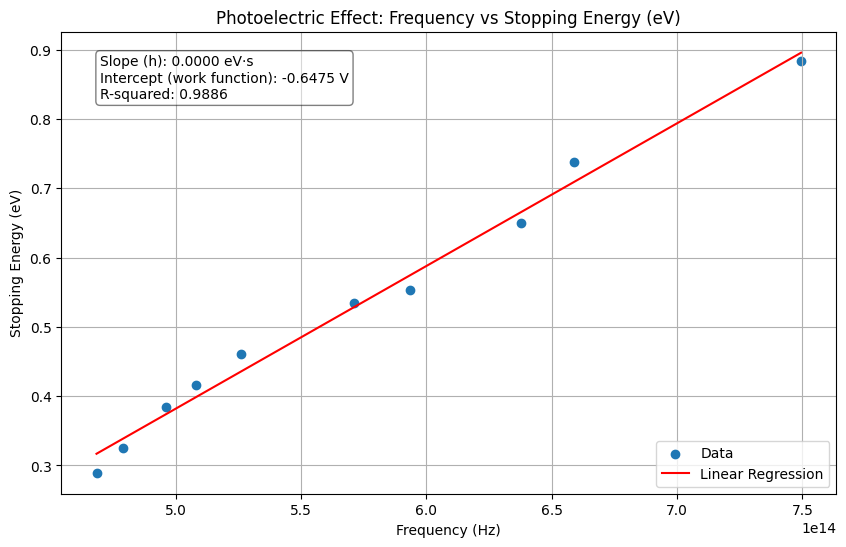

In [80]:
from scipy import stats
import matplotlib.pyplot as plt

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["frequency"], df["stopping_voltage_V"]
)

print(f"Slope (h): {slope} eV·s")
print(f"Intercept (work function): {intercept} V")
print(f"R-squared: {r_value**2}")
print(f"Standard Error: {std_err} eV·s")
print(f"p-value: {p_value}")

plt.figure(figsize=(10, 6))
plt.scatter(df["frequency"], df["stopping_voltage_V"], label="Data")
plt.plot(
    df["frequency"],
    intercept + slope * df["frequency"],
    color="red",
    label="Linear Regression",
)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Stopping Energy (eV)")
plt.title("Photoelectric Effect: Frequency vs Stopping Energy (eV)")
plt.legend()
plt.grid(True)
plt.text(
    0.05,
    0.95,
    f"Slope (h): {slope:.4f} eV·s\nIntercept (work function): {intercept:.4f} V\nR-squared: {r_value**2:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5),
)
plt.show()
